# Analysis: Multiple Alpha (Experiment 3)
## Dose-Response Relationship Between Empathy Weight and Collective Cooperation

This notebook implements the analysis plan from `prereg_multiple_alpha.md`.

**Design**: 7 alpha levels {0.0, 0.15, 0.25, 0.5, 0.75, 0.85, 0.99}, all with `see_emotions=True`, 3 runs each.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import os
import re
import ast
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Helper Functions
Reused from `jerome_analysis_first.ipynb`

In [2]:
# --- Gini coefficient ---

def gini_coefficient(arr: np.ndarray) -> float:
    """Compute Gini coefficient of a 1D numpy array."""
    arr = arr.flatten()
    if np.amin(arr) < 0:
        arr = arr - np.amin(arr)
    mean = np.mean(arr)
    if mean == 0:
        return 0.0
    n = len(arr)
    diff_sum = np.sum(np.abs(np.subtract.outer(arr, arr)))
    gini = diff_sum / (2 * n**2 * mean)
    return gini


def parse_value(val):
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, (list, tuple, np.ndarray)):
                return np.array(parsed, dtype=float)
            else:
                return float(parsed)
        except (ValueError, SyntaxError):
            return float(val)
    elif isinstance(val, (list, tuple, np.ndarray)):
        return np.array(val, dtype=float)
    else:
        return float(val)


def compute_gini_for_df(df: pd.DataFrame, prefix: str) -> pd.Series:
    """Compute Gini coefficient across columns starting with prefix for each row."""
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    def row_gini(row):
        values = []
        for val in row.values:
            parsed_val = parse_value(val)
            if isinstance(parsed_val, np.ndarray):
                values.extend(parsed_val.flatten())
            else:
                values.append(parsed_val)
        values = np.array(values, dtype=float)
        return gini_coefficient(values)

    return df[cols].apply(row_gini, axis=1)

In [3]:
# --- Efficiency ---

def compute_efficiency_for_df(df: pd.DataFrame, prefix: str, new_column_name: str) -> pd.DataFrame:
    """Compute the average across columns starting with a given prefix for each row."""
    cols = [col for col in df.columns if col.startswith(prefix)]
    if not cols:
        raise ValueError(f"No columns found starting with prefix '{prefix}'")

    for col in cols:
        def parse_cell(val):
            if isinstance(val, (float, int)):
                return float(val)
            if isinstance(val, str):
                try:
                    parsed = ast.literal_eval(val)
                    if isinstance(parsed, list) and len(parsed) == 1:
                        return float(parsed[0])
                    return float(parsed)
                except Exception:
                    raise ValueError(f"Value '{val}' in column '{col}' could not be parsed to float.")
            raise ValueError(f"Unsupported value type {type(val)} in column '{col}'.")
        df[col] = df[col].apply(parse_cell)

    df[new_column_name] = df[cols].mean(axis=1)
    return df

In [4]:
# --- Resource depletion ---

def _clean_initial_resources_column(df: pd.DataFrame, col_name: str) -> None:
    """Convert list-like string in initial_resources column to numeric."""
    def extract_number(x):
        if pd.isna(x):
            return np.nan
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple)) and len(parsed) > 0:
                return float(parsed[0])
            else:
                return np.nan
        except:
            return np.nan

    if col_name in df.columns and df[col_name].dtype == object:
        df[col_name] = df[col_name].apply(extract_number)
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce')


def GT_compute_depletion_from_summary(df: pd.DataFrame) -> None:
    _clean_initial_resources_column(df, 'initial_resources')
    df.loc[:, 'depletion_final'] = 1 - df['resource_remaining'] / df['initial_resources']
    df.loc[:, 'depletion_early'] = 1 - df['total_steps'] / df['max_steps']

In [5]:
# --- Learning curve visualization ---

def windowed_avg_combined_reward(
    df: pd.DataFrame,
    reward_prefix: str = "total_combined_reward_",
    episode_column: str = "episode",
    simulation_id_column: str = "simulation_index",
    window_size: int = 5,
    aggregation_mode: str = "mean",
    plot: bool = False
) -> pd.DataFrame:
    reward_cols = [col for col in df.columns if col.startswith(reward_prefix)]
    if not reward_cols:
        raise ValueError(f"No columns found with prefix '{reward_prefix}'")

    df = df.copy()
    if aggregation_mode == "mean":
        df["aggregated_reward"] = df[reward_cols].mean(axis=1)
    elif aggregation_mode == "best":
        df["aggregated_reward"] = df[reward_cols].max(axis=1)
    else:
        raise ValueError("aggregation_mode must be 'mean' or 'best'")

    episode_avg = (
        df.groupby(episode_column)["aggregated_reward"]
        .mean()
        .reset_index()
        .rename(columns={"aggregated_reward": "mean_reward"})
    )
    episode_avg["moving_avg"] = (
        episode_avg["mean_reward"].rolling(window=window_size, min_periods=1, center=True).mean()
    )

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(episode_avg[episode_column], episode_avg["moving_avg"], label=f"Moving Avg ({aggregation_mode})")
        plt.xlabel("Episode")
        plt.ylabel("Reward")
        plt.title(f"{aggregation_mode.capitalize()} Agent Reward (Window={window_size})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return episode_avg

In [6]:
# --- Mean and range plot ---

def plot_mean_and_range_across_simulations(
    df: pd.DataFrame,
    value_col: str,
    simulation_col: str = 'seed',
    episode_col: str = 'episode',
    step_col: str = 'step',
    is_step_csv: bool = False,
    title: str = None,
    ylabel: str = None,
    rolling_window: int = None,
    plot_individual: bool = False
):
    if is_step_csv:
        group_cols = [simulation_col, episode_col, step_col]
        avg_group_cols = [episode_col, step_col]
    else:
        group_cols = [simulation_col, episode_col]
        avg_group_cols = [episode_col]

    sim_stats = df.groupby(group_cols)[value_col].mean().reset_index()
    agg_funcs = {value_col: ['mean', 'min', 'max']}
    summary = sim_stats.groupby(avg_group_cols).agg(agg_funcs)
    summary.columns = ['mean', 'min', 'max']
    summary = summary.reset_index()

    if rolling_window and rolling_window > 1:
        summary['mean'] = summary['mean'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['min'] = summary['min'].rolling(rolling_window, min_periods=1, center=True).mean()
        summary['max'] = summary['max'].rolling(rolling_window, min_periods=1, center=True).mean()

    plt.figure(figsize=(10, 6))
    if plot_individual:
        for sim_id, sim_df in sim_stats.groupby(simulation_col):
            x = sim_df[episode_col] if not is_step_csv else sim_df[step_col]
            y = sim_df[value_col]
            if rolling_window:
                y = y.rolling(rolling_window, min_periods=1).mean()
            plt.plot(x, y, color='gray', alpha=0.3, label=f"Sim {sim_id}")

    x_vals = summary[episode_col] if not is_step_csv else summary[step_col]
    plt.fill_between(x_vals, summary['min'], summary['max'], color='blue', alpha=0.2, label='Range (min-max)')
    plt.plot(x_vals, summary['mean'], color='blue', linewidth=2, label='Mean')
    plt.xlabel('Episode' if not is_step_csv else 'Step')
    plt.ylabel(ylabel if ylabel else value_col)
    plt.title(title or f"Fluctuation of {value_col} with range")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## 3. Data Loading

In [7]:
# Filename regex for DQN game-theoretic results
FILENAME_PATTERN = re.compile(
    r"results_(?P<simulation_index>\d{3})_(?P<episodes>\d+)_DQN_"
    r"(?P<emotion>[^_]+)_(?P<see_emotions>[^_]+)_"
    r"(?P<alpha>[\d.]+)_(?P<beta>[\d.]+)_(?P<smoothing>[^_]+)_(?P<threshold>[\d.]+)_(?P<rounder>[\d.]+)_"
    r"(?P<learning_rate>[\d.]+)_(?P<gamma>[\d.]+)_(?P<epsilon>[\d.]+)_(?P<epsilon_decay>[\d.]+)_(?P<epsilon_min>[\d.]+)_"
    r"(?P<batch_size>[\d.]+)_(?P<hidden_size>[\d.]+)_(?P<update_target_every>[\d.]+)_"
    r"(?P<random_suffix>\d{6})_(?P<suffix>[a-zA-Z]+_[a-zA-Z]+)\.csv"
)

# Works from repo root (VS Code) or from this folder (Jupyter)
DATA_DIR = 'GT_simulation_2_MultipleAlpha' if os.path.isdir('GT_simulation_2_MultipleAlpha') else '.'

# Load and tag all episode_summary CSVs
all_dfs = []
run_counter = 0
for filename in sorted(os.listdir(DATA_DIR)):
    if not filename.endswith('.csv') or ' copy' in filename:
        continue
    match = FILENAME_PATTERN.match(filename)
    if match and match.group('suffix') == 'episode_summary':
        meta = match.groupdict()
        filepath = os.path.join(DATA_DIR, filename)
        df_tmp = pd.read_csv(filepath)
        df_tmp['alpha'] = float(meta['alpha'])
        df_tmp['run_id'] = run_counter
        df_tmp['see_emotions'] = meta['see_emotions']
        all_dfs.append(df_tmp)
        run_counter += 1

df = pd.concat(all_dfs, ignore_index=True)
print(f'Loaded {len(all_dfs)} files, {len(df)} total rows')
print(f'Alpha levels: {sorted(df["alpha"].unique())}')
print(f'Runs per alpha: {df.groupby("alpha")["run_id"].nunique().to_dict()}')


Loaded 36 files, 18325 total rows
Alpha levels: [np.float64(0.0), np.float64(0.15), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(0.85), np.float64(0.99)]
Runs per alpha: {0.0: 6, 0.15: 5, 0.25: 5, 0.5: 5, 0.75: 5, 0.85: 5, 0.99: 5}


## 4. Dependent Variable Computation

In [8]:
# Depletion
GT_compute_depletion_from_summary(df)

# Gini coefficient on personal rewards
df['gini_personal_reward'] = compute_gini_for_df(df, prefix='total_personal_reward_')

# Episode length is already in total_steps

# Efficiency (exploratory)
compute_efficiency_for_df(df, prefix='total_personal_reward_', new_column_name='efficiency')

print("DVs computed successfully.")
print(df[['alpha', 'total_steps', 'depletion_final', 'gini_personal_reward', 'efficiency']].describe())

DVs computed successfully.
              alpha   total_steps  depletion_final  gini_personal_reward  \
count  18325.000000  18325.000000     18325.000000          18325.000000   
mean       0.473561    830.263356         0.997643              0.238774   
std        0.360712    167.938623         0.006448              0.148887   
min        0.000000    358.000000         0.850000              0.005121   
25%        0.150000    688.000000         0.998000              0.117956   
50%        0.500000    862.000000         1.000000              0.198189   
75%        0.850000   1000.000000         1.000000              0.350315   
max        0.990000   1000.000000         1.000000              0.683716   

         efficiency  
count  18325.000000  
mean      83.083326  
std        0.524034  
min       70.833333  
25%       83.166667  
50%       83.258333  
75%       83.258333  
max       83.350000  


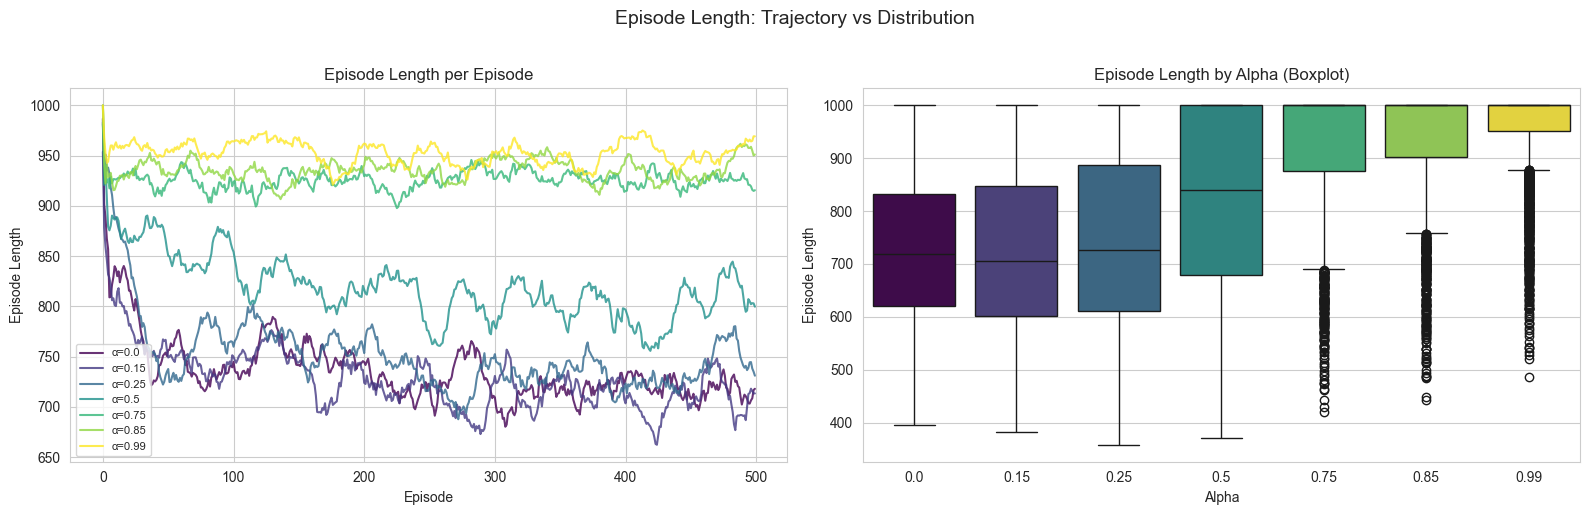

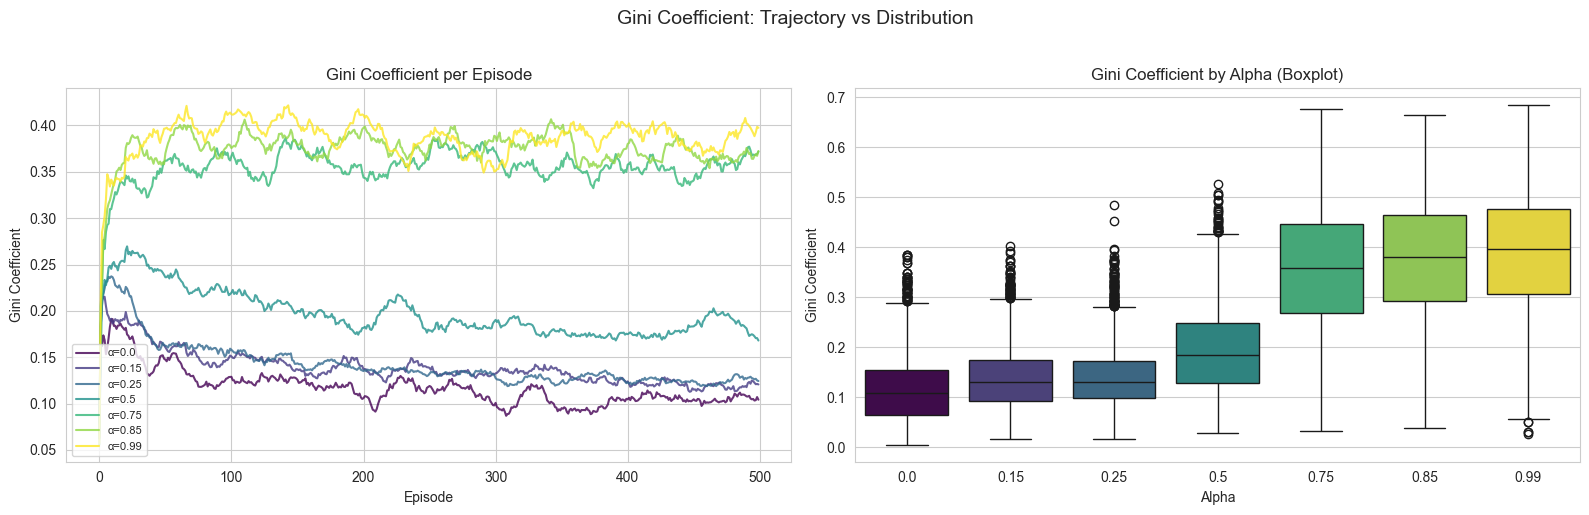

In [9]:
# --- Side-by-side plots: per-episode trajectory + boxplot ---

alpha_levels = sorted(df['alpha'].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(alpha_levels)))
palette = {str(a): c for a, c in zip(alpha_levels, colors)}
window_size = 20

for dv, label in [('total_steps', 'Episode Length'), ('gini_personal_reward', 'Gini Coefficient')]:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Left: per-episode trajectory (smoothed, one line per alpha)
    for alpha_val, color in zip(alpha_levels, colors):
        subset = df[df['alpha'] == alpha_val]
        ep_mean = subset.groupby('episode')[dv].mean()
        ep_smooth = ep_mean.rolling(window=window_size, min_periods=1).mean()
        ax1.plot(ep_smooth.index, ep_smooth.values, color=color, label=f'α={alpha_val}', alpha=0.8)
    ax1.set_xlabel('Episode')
    ax1.set_ylabel(label)
    ax1.set_title(f'{label} per Episode')
    ax1.legend(fontsize=8)

    # Right: boxplot by alpha (same color mapping)
    sns.boxplot(data=df, x='alpha', y=dv, ax=ax2, palette=palette, order=alpha_levels)
    ax2.set_xlabel('Alpha')
    ax2.set_ylabel(label)
    ax2.set_title(f'{label} by Alpha (Boxplot)')

    fig.suptitle(f'{label}: Trajectory vs Distribution', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


## 5. Descriptive Statistics

In [10]:
# Summary table: mean +/- SD per alpha level
primary_dvs = ['depletion_final', 'total_steps', 'gini_personal_reward']
alpha_levels = sorted(df['alpha'].unique())

desc_rows = []
for alpha in alpha_levels:
    subset = df[df['alpha'] == alpha]
    row = {'alpha': alpha}
    for dv in primary_dvs:
        row[f'{dv}_mean'] = subset[dv].mean()
        row[f'{dv}_sd'] = subset[dv].std()
    desc_rows.append(row)

desc_df = pd.DataFrame(desc_rows)
print(desc_df.to_string(index=False))

 alpha  depletion_final_mean  depletion_final_sd  total_steps_mean  total_steps_sd  gini_personal_reward_mean  gini_personal_reward_sd
  0.00              0.999795            0.000714        734.442924      145.742388                   0.116997                 0.066154
  0.15              0.999730            0.000910        727.916279      159.606967                   0.138931                 0.066125
  0.25              0.999601            0.001232        748.805313      163.221344                   0.140742                 0.061903
  0.50              0.998783            0.002942        817.113200      167.694802                   0.196444                 0.086866
  0.75              0.996338            0.006734        925.190800      116.999010                   0.356813                 0.120630
  0.85              0.995370            0.008137        935.972800      110.237435                   0.376307                 0.121910
  0.99              0.993166            0.011790       

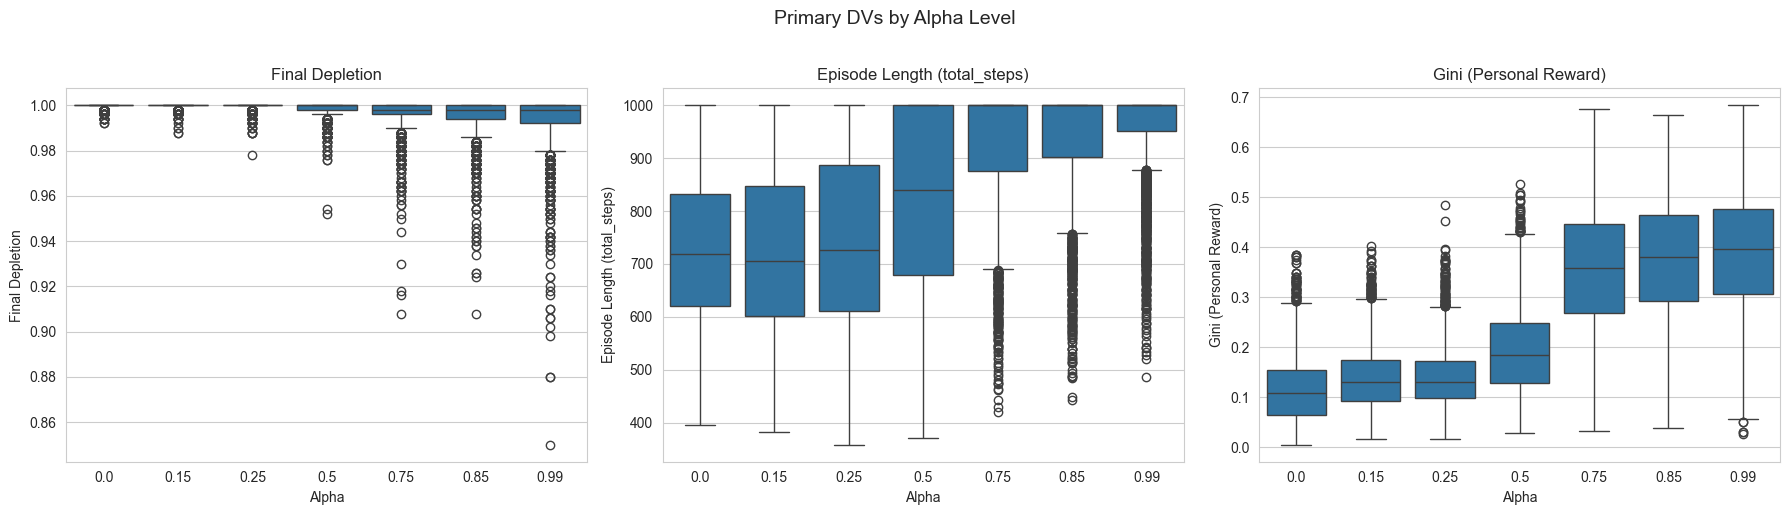

In [11]:
# Boxplots per alpha level for each DV
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dv_labels = ['Final Depletion', 'Episode Length (total_steps)', 'Gini (Personal Reward)']

for ax, dv, label in zip(axes, primary_dvs, dv_labels):
    sns.boxplot(data=df, x='alpha', y=dv, ax=ax)
    ax.set_title(label)
    ax.set_xlabel('Alpha')
    ax.set_ylabel(label)

plt.suptitle('Primary DVs by Alpha Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. H1 — Monotonic Resource Preservation (Confirmatory)

**Hypothesis**: Increasing alpha monotonically improves resource preservation (lower depletion, longer episodes).

Tests: Jonckheere-Terpstra trend test, linear regression, Kruskal-Wallis, post-hoc pairwise Mann-Whitney.

Bonferroni correction across 3 primary DVs: alpha_corrected = 0.05/3 = 0.0167.

In [12]:
# Aggregate to run-level means (N=3 per alpha) for group-level tests
run_means = df.groupby(['alpha', 'run_id'])[primary_dvs].mean().reset_index()
print(f"Run-level observations: {len(run_means)} (expected: 21 = 7 alpha x 3 runs)")
run_means.head(10)

Run-level observations: 36 (expected: 21 = 7 alpha x 3 runs)


,alpha,run_id,depletion_final,total_steps,gini_personal_reward
0,0.00,0,0.999832,731.348000,0.114028
1,0.00,1,0.999800,732.830000,0.118924
2,0.00,14,0.999832,731.348000,0.114028
3,0.00,15,0.999768,736.180000,0.117453
4,0.00,28,0.999768,736.180000,0.117453
5,0.00,35,0.999582,763.973856,0.130522
6,0.15,2,0.999696,743.228000,0.137017
7,0.15,3,0.999760,714.690000,0.136733
8,0.15,16,0.999828,720.542000,0.139120
9,0.15,17,0.999280,766.333333,0.160671


In [13]:
# --- Jonckheere-Terpstra trend test (manual implementation) ---
# Tests for ordered alternatives: does the DV increase/decrease monotonically with alpha?

def jonckheere_terpstra_test(groups, alternative='increasing'):
    """
    Manual Jonckheere-Terpstra test for ordered alternatives.
    groups: list of arrays, ordered by the expected trend.
    alternative: 'increasing' or 'decreasing'
    Returns: J statistic, z-score, p-value
    """
    k = len(groups)
    J = 0
    for i in range(k - 1):
        for j in range(i + 1, k):
            for xi in groups[i]:
                for xj in groups[j]:
                    if xj > xi:
                        J += 1
                    elif xj == xi:
                        J += 0.5

    # Expected value and variance under H0
    n = [len(g) for g in groups]
    N = sum(n)
    E_J = (N**2 - sum(ni**2 for ni in n)) / 4
    var_num = N**2 * (2 * N + 3) - sum(ni**2 * (2 * ni + 3) for ni in n)
    var_J = var_num / 72

    z = (J - E_J) / np.sqrt(var_J)

    if alternative == 'increasing':
        p = 1 - stats.norm.cdf(z)
    elif alternative == 'decreasing':
        p = stats.norm.cdf(z)
    else:
        p = 2 * (1 - stats.norm.cdf(abs(z)))

    return J, z, p


print("=" * 70)
print("H1: JONCKHEERE-TERPSTRA TREND TEST")
print("=" * 70)

bonferroni_alpha = 0.05 / 3  # correction across 3 primary DVs

for dv in primary_dvs:
    groups = [run_means[run_means['alpha'] == a][dv].values for a in alpha_levels]

    # For depletion: expect DECREASING with alpha
    # For total_steps: expect INCREASING with alpha
    if 'depletion' in dv:
        alternative = 'decreasing'
    else:
        alternative = 'increasing'

    J, z, p = jonckheere_terpstra_test(groups, alternative=alternative)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < bonferroni_alpha else 'ns'
    print(f"\n{dv} (expected {alternative}):")
    print(f"  J = {J:.1f}, z = {z:.3f}, p = {p:.6f} [{sig}] (corrected alpha = {bonferroni_alpha:.4f})")

H1: JONCKHEERE-TERPSTRA TREND TEST

depletion_final (expected decreasing):
  J = 18.0, z = -7.155, p = 0.000000 [***] (corrected alpha = 0.0167)

total_steps (expected increasing):
  J = 524.0, z = 6.796, p = 0.000000 [***] (corrected alpha = 0.0167)

gini_personal_reward (expected increasing):
  J = 549.0, z = 7.486, p = 0.000000 [***] (corrected alpha = 0.0167)


In [14]:
# --- Linear regression: DV ~ alpha ---
print("=" * 70)
print("H1: LINEAR REGRESSION (DV ~ alpha)")
print("=" * 70)

for dv in primary_dvs:
    X = sm.add_constant(run_means['alpha'])
    y = run_means[dv]
    model = sm.OLS(y, X).fit()
    slope = model.params.iloc[1]
    r_sq = model.rsquared
    p_val = model.pvalues.iloc[1]
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < bonferroni_alpha else 'ns'
    print(f"\n{dv}:")
    print(f"  slope = {slope:.4f}, R² = {r_sq:.4f}, p = {p_val:.6f} [{sig}]")

H1: LINEAR REGRESSION (DV ~ alpha)

depletion_final:
  slope = -0.0064, R² = 0.8779, p = 0.000000 [***]

total_steps:
  slope = 253.7552, R² = 0.9369, p = 0.000000 [***]

gini_personal_reward:
  slope = 0.3100, R² = 0.9345, p = 0.000000 [***]


In [15]:
# --- Post-hoc pairwise Mann-Whitney: each alpha vs. alpha=0.0 ---
print("=" * 70)
print("H1: POST-HOC PAIRWISE MANN-WHITNEY (vs. alpha=0.0)")
print("Bonferroni correction: 6 comparisons per DV, alpha = 0.05/6 = 0.0083")
print("=" * 70)

bonferroni_pairwise = 0.05 / 6
baseline = run_means[run_means['alpha'] == 0.0]

for dv in primary_dvs:
    print(f"\n--- {dv} ---")
    for alpha_val in alpha_levels:
        if alpha_val == 0.0:
            continue
        group = run_means[run_means['alpha'] == alpha_val]

        if 'depletion' in dv:
            alt = 'less'  # expect lower depletion
        else:
            alt = 'greater'  # expect higher steps/gini-reduction

        U, p = mannwhitneyu(group[dv].values, baseline[dv].values, alternative=alt)
        sig = '*' if p < bonferroni_pairwise else 'ns'
        print(f"  alpha={alpha_val} vs 0.0: U={U:.1f}, p={p:.6f} [{sig}]")

H1: POST-HOC PAIRWISE MANN-WHITNEY (vs. alpha=0.0)
Bonferroni correction: 6 comparisons per DV, alpha = 0.05/6 = 0.0083

--- depletion_final ---
  alpha=0.15 vs 0.0: U=9.0, p=0.156546 [ns]
  alpha=0.25 vs 0.0: U=3.0, p=0.017463 [ns]
  alpha=0.5 vs 0.0: U=0.0, p=0.003914 [*]
  alpha=0.75 vs 0.0: U=0.0, p=0.003914 [*]
  alpha=0.85 vs 0.0: U=0.0, p=0.003914 [*]
  alpha=0.99 vs 0.0: U=0.0, p=0.003914 [*]

--- total_steps ---
  alpha=0.15 vs 0.0: U=11.0, p=0.795412 [ns]
  alpha=0.25 vs 0.0: U=24.0, p=0.059500 [ns]
  alpha=0.5 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.75 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.85 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.99 vs 0.0: U=30.0, p=0.003914 [*]

--- gini_personal_reward ---
  alpha=0.15 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.25 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.5 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.75 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.85 vs 0.0: U=30.0, p=0.003914 [*]
  alpha=0.99 vs 0.0: U=30.0, p=0.003914 [*]


## 7. H2 — Monotonic Inequality Reduction (Confirmatory)

**Hypothesis**: Increasing alpha reduces Gini coefficient (expected negative trend).

Same tests as H1, applied to Gini.

In [16]:
# H2 tests are already included in the H1 cells above for gini_personal_reward.
# Summarize the Gini-specific results:

dv = 'gini_personal_reward'
groups = [run_means[run_means['alpha'] == a][dv].values for a in alpha_levels]

print("=" * 70)
print("H2: GINI COEFFICIENT TREND ANALYSIS")
print("=" * 70)

# Trend test (expect decreasing Gini with alpha)
J, z, p = jonckheere_terpstra_test(groups, alternative='decreasing')
print(f"Jonckheere-Terpstra (decreasing): J={J:.1f}, z={z:.3f}, p={p:.6f}")

# Regression
X = sm.add_constant(run_means['alpha'])
y = run_means[dv]
model = sm.OLS(y, X).fit()
print(f"Linear regression: slope={model.params.iloc[1]:.4f}, R²={model.rsquared:.4f}, p={model.pvalues.iloc[1]:.6f}")

# Kruskal-Wallis
H, p_kw = kruskal(*groups)
print(f"Kruskal-Wallis: H={H:.3f}, p={p_kw:.6f}")

# Mean Gini per alpha
print("\nMean Gini per alpha level:")
for alpha_val in alpha_levels:
    subset = run_means[run_means['alpha'] == alpha_val][dv]
    print(f"  alpha={alpha_val}: {subset.mean():.4f} +/- {subset.std():.4f}")

H2: GINI COEFFICIENT TREND ANALYSIS
Jonckheere-Terpstra (decreasing): J=549.0, z=7.486, p=1.000000
Linear regression: slope=0.3100, R²=0.9345, p=0.000000
Kruskal-Wallis: H=33.900, p=0.000007

Mean Gini per alpha level:
  alpha=0.0: 0.1187 +/- 0.0061
  alpha=0.15: 0.1420 +/- 0.0105
  alpha=0.25: 0.1408 +/- 0.0027
  alpha=0.5: 0.1964 +/- 0.0074
  alpha=0.75: 0.3568 +/- 0.0103
  alpha=0.85: 0.3763 +/- 0.0045
  alpha=0.99: 0.3882 +/- 0.0025


## 8. H3 — Nonlinear Threshold Effect (Exploratory)

Visual inspection of dose-response curves. Segmented regression to detect breakpoint.

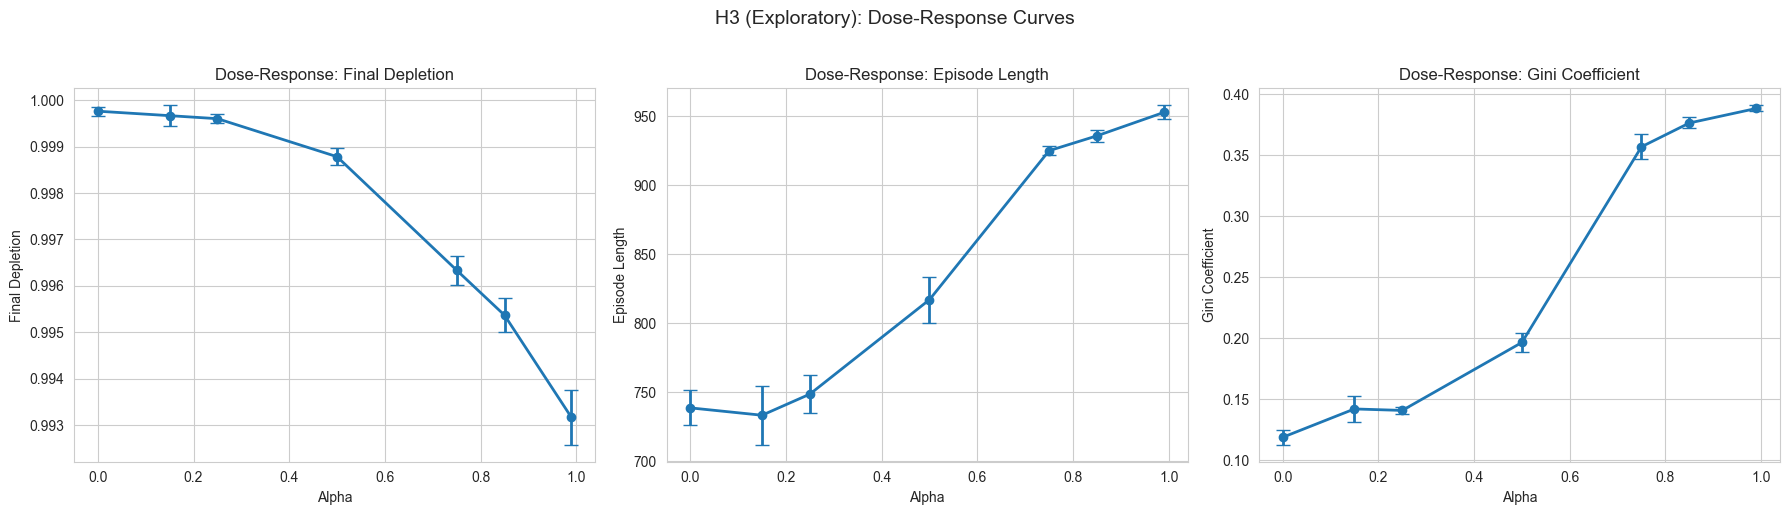

In [17]:
# Dose-response curves with error bars
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dv_labels = ['Final Depletion', 'Episode Length', 'Gini Coefficient']

for ax, dv, label in zip(axes, primary_dvs, dv_labels):
    means = [run_means[run_means['alpha'] == a][dv].mean() for a in alpha_levels]
    sds = [run_means[run_means['alpha'] == a][dv].std() for a in alpha_levels]
    ax.errorbar(alpha_levels, means, yerr=sds, marker='o', capsize=5, linewidth=2)
    ax.set_xlabel('Alpha')
    ax.set_ylabel(label)
    ax.set_title(f'Dose-Response: {label}')
    ax.grid(True)

plt.suptitle('H3 (Exploratory): Dose-Response Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Segmented regression: test for breakpoint
# Simple approach: fit piecewise linear with each alpha as candidate breakpoint

print("=" * 70)
print("H3 (EXPLORATORY): SEGMENTED REGRESSION — BREAKPOINT DETECTION")
print("=" * 70)

for dv in primary_dvs:
    best_aic = np.inf
    best_bp = None
    best_model = None

    x = run_means['alpha'].values
    y = run_means[dv].values

    # Try each inner alpha as breakpoint
    for bp in alpha_levels[1:-1]:
        x1 = x.copy()
        x2 = np.maximum(0, x - bp)
        X_seg = sm.add_constant(np.column_stack([x1, x2]))
        model = sm.OLS(y, X_seg).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_bp = bp
            best_model = model

    # Compare with simple linear
    X_lin = sm.add_constant(x)
    model_lin = sm.OLS(y, X_lin).fit()

    print(f"\n{dv}:")
    print(f"  Linear model AIC: {model_lin.aic:.2f}")
    print(f"  Best segmented model AIC: {best_aic:.2f} (breakpoint at alpha={best_bp})")
    print(f"  Segmented better: {best_aic < model_lin.aic}")

H3 (EXPLORATORY): SEGMENTED REGRESSION — BREAKPOINT DETECTION

depletion_final:
  Linear model AIC: -403.36
  Best segmented model AIC: -466.08 (breakpoint at alpha=0.5)
  Segmented better: True

total_steps:
  Linear model AIC: 333.14
  Best segmented model AIC: 312.36 (breakpoint at alpha=0.15)
  Segmented better: True

gini_personal_reward:
  Linear model AIC: -148.34
  Best segmented model AIC: -166.14 (breakpoint at alpha=0.25)
  Segmented better: True


## 9. H4 — Diminishing Returns at High Alpha (Exploratory)

H4 (EXPLORATORY): MARGINAL GAINS BETWEEN CONSECUTIVE ALPHA LEVELS

depletion_final:
  0.0->0.15: -0.0001
  0.15->0.25: -0.0001
  0.25->0.5: -0.0008
  0.5->0.75: -0.0024
  0.75->0.85: -0.0010
  0.85->0.99: -0.0022

total_steps:
  0.0->0.15: -5.3486
  0.15->0.25: +15.3221
  0.25->0.5: +68.4964
  0.5->0.75: +108.0776
  0.75->0.85: +10.7820
  0.85->0.99: +17.0100

gini_personal_reward:
  0.0->0.15: +0.0232
  0.15->0.25: -0.0012
  0.25->0.5: +0.0557
  0.5->0.75: +0.1604
  0.75->0.85: +0.0195
  0.85->0.99: +0.0119


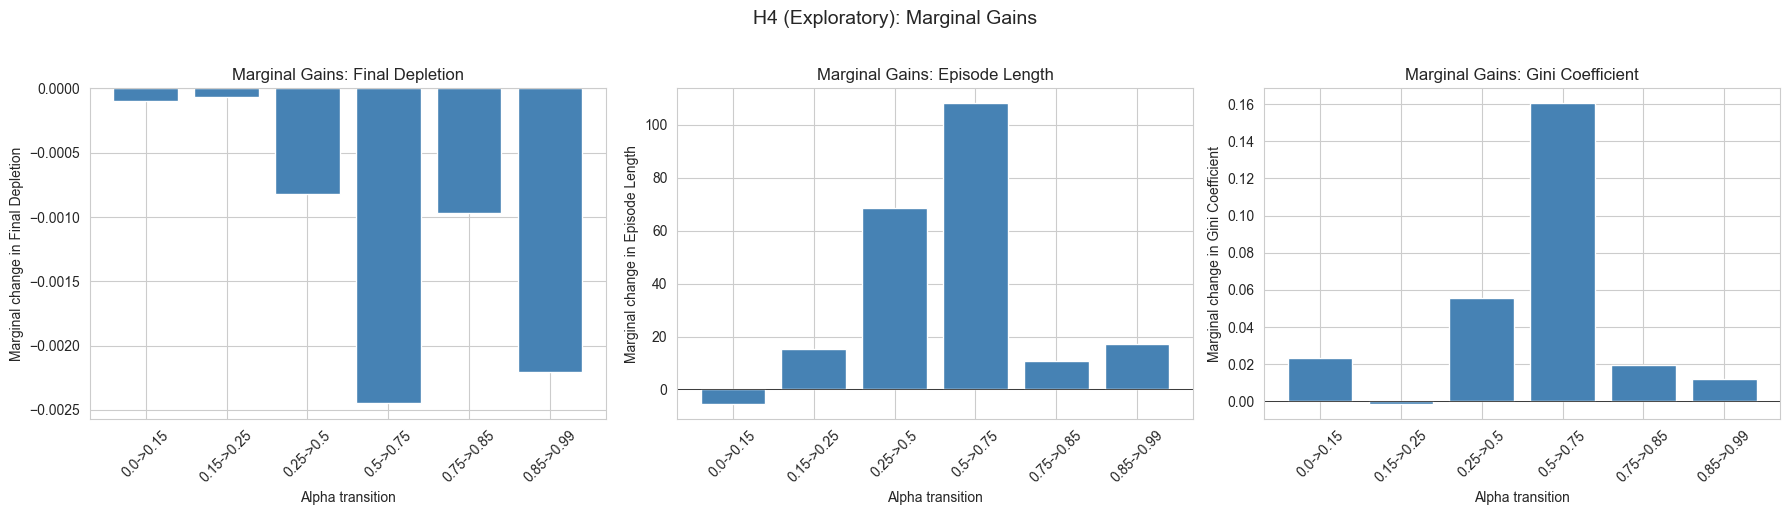

In [19]:
# Marginal gains between consecutive alpha levels
print("=" * 70)
print("H4 (EXPLORATORY): MARGINAL GAINS BETWEEN CONSECUTIVE ALPHA LEVELS")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dv, label in zip(axes, primary_dvs, dv_labels):
    means = [run_means[run_means['alpha'] == a][dv].mean() for a in alpha_levels]
    marginal = [means[i+1] - means[i] for i in range(len(means)-1)]
    labels = [f"{alpha_levels[i]}->{alpha_levels[i+1]}" for i in range(len(alpha_levels)-1)]

    ax.bar(range(len(marginal)), marginal, tick_label=labels, color='steelblue')
    ax.set_xlabel('Alpha transition')
    ax.set_ylabel(f'Marginal change in {label}')
    ax.set_title(f'Marginal Gains: {label}')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, axis='y')

    print(f"\n{dv}:")
    for l, m in zip(labels, marginal):
        print(f"  {l}: {m:+.4f}")

plt.suptitle('H4 (Exploratory): Marginal Gains', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Learning Trajectories (Exploratory)

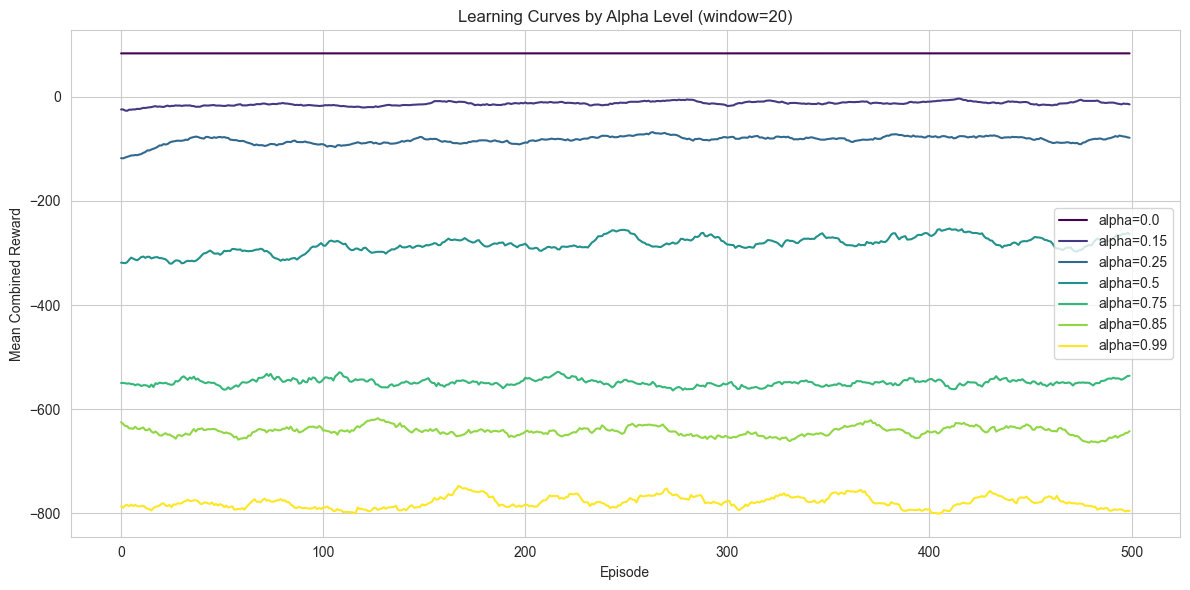

In [20]:
# Overlay learning curves for all alpha values
window_size = 20
colors = plt.cm.viridis(np.linspace(0, 1, len(alpha_levels)))

plt.figure(figsize=(12, 6))
for alpha_val, color in zip(alpha_levels, colors):
    subset = df[df['alpha'] == alpha_val]
    episode_avg = windowed_avg_combined_reward(
        df=subset, reward_prefix='total_combined_reward_',
        episode_column='episode', window_size=window_size, plot=False
    )
    plt.plot(episode_avg['episode'], episode_avg['moving_avg'],
             label=f'alpha={alpha_val}', color=color, linewidth=1.5)

plt.xlabel('Episode')
plt.ylabel('Mean Combined Reward')
plt.title(f'Learning Curves by Alpha Level (window={window_size})')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

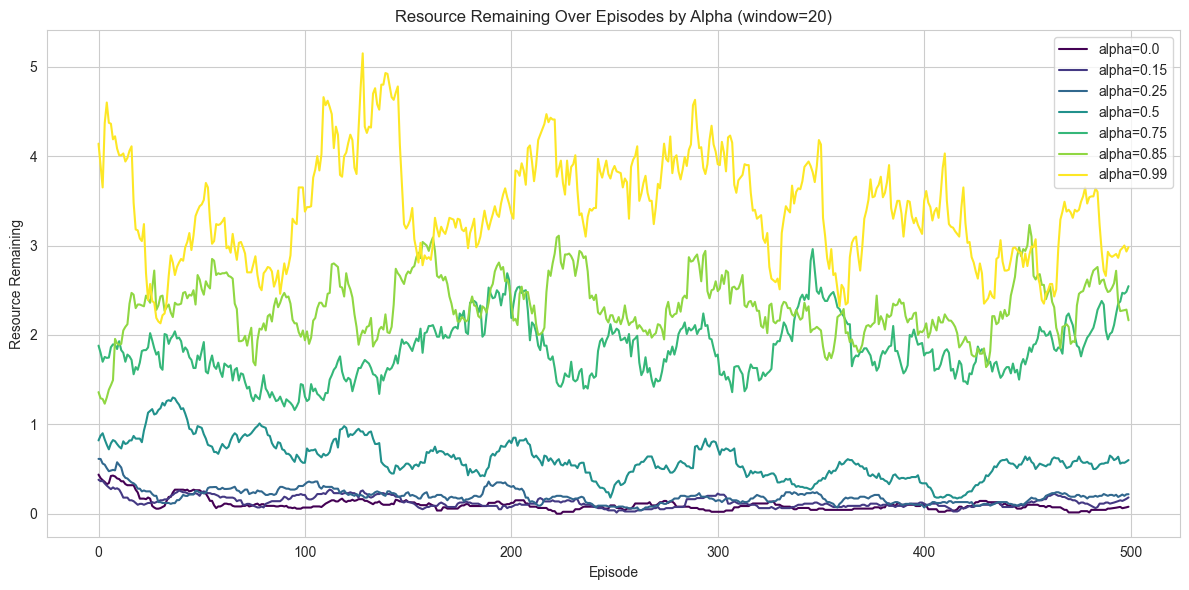

In [21]:
# Resource depletion trajectory over episodes per alpha
plt.figure(figsize=(12, 6))
for alpha_val, color in zip(alpha_levels, colors):
    subset = df[df['alpha'] == alpha_val]
    ep_mean = subset.groupby('episode')['resource_remaining'].mean()
    ep_smooth = ep_mean.rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(ep_smooth.index, ep_smooth.values, label=f'alpha={alpha_val}', color=color, linewidth=1.5)

plt.xlabel('Episode')
plt.ylabel('Resource Remaining')
plt.title(f'Resource Remaining Over Episodes by Alpha (window={window_size})')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

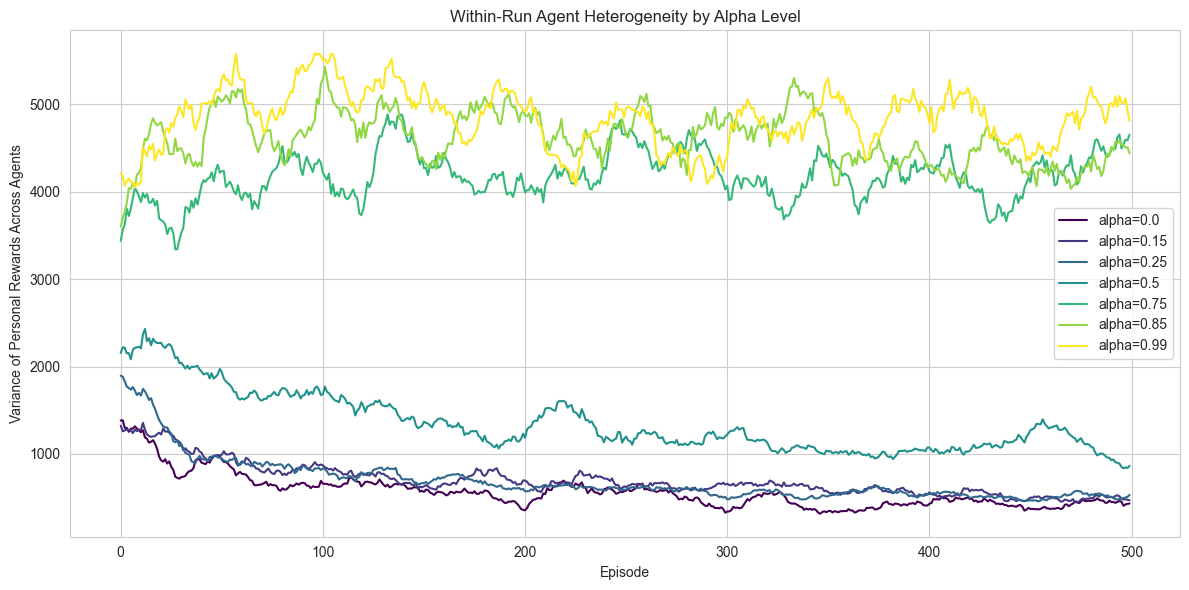

In [22]:
# Within-run agent heterogeneity: variance of personal rewards across 6 agents per episode
reward_cols = [f'total_personal_reward_{i}' for i in range(6)]
df['agent_reward_var'] = df[reward_cols].astype(float).var(axis=1)

plt.figure(figsize=(12, 6))
for alpha_val, color in zip(alpha_levels, colors):
    subset = df[df['alpha'] == alpha_val]
    ep_mean = subset.groupby('episode')['agent_reward_var'].mean()
    ep_smooth = ep_mean.rolling(window=window_size, min_periods=1, center=True).mean()
    plt.plot(ep_smooth.index, ep_smooth.values, label=f'alpha={alpha_val}', color=color, linewidth=1.5)

plt.xlabel('Episode')
plt.ylabel('Variance of Personal Rewards Across Agents')
plt.title('Within-Run Agent Heterogeneity by Alpha Level')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. Summary Table

In [23]:
# Build summary table of all hypothesis tests
summary_results = []

for dv in primary_dvs:
    groups = [run_means[run_means['alpha'] == a][dv].values for a in alpha_levels]

    # Direction
    if 'depletion' in dv:
        alt_jt = 'decreasing'
        alt_mw = 'less'
    elif 'gini' in dv:
        alt_jt = 'decreasing'
        alt_mw = 'less'
    else:
        alt_jt = 'increasing'
        alt_mw = 'greater'

    # JT
    J, z, p_jt = jonckheere_terpstra_test(groups, alternative=alt_jt)
    summary_results.append({
        'Hypothesis': 'H1' if 'gini' not in dv else 'H2',
        'DV': dv, 'Test': 'Jonckheere-Terpstra',
        'Statistic': f'J={J:.1f}, z={z:.3f}', 'p-value': f'{p_jt:.6f}',
        'Corrected alpha': '0.0167',
        'Significant': 'Yes' if p_jt < 0.0167 else 'No'
    })

    # Regression
    X = sm.add_constant(run_means['alpha'])
    model = sm.OLS(run_means[dv], X).fit()
    p_reg = model.pvalues.iloc[1]
    summary_results.append({
        'Hypothesis': 'H1' if 'gini' not in dv else 'H2',
        'DV': dv, 'Test': 'Linear Regression',
        'Statistic': f'slope={model.params.iloc[1]:.4f}, R²={model.rsquared:.4f}',
        'p-value': f'{p_reg:.6f}',
        'Corrected alpha': '0.0167',
        'Significant': 'Yes' if p_reg < 0.0167 else 'No'
    })

    # KW
    H, p_kw = kruskal(*groups)
    summary_results.append({
        'Hypothesis': 'H1' if 'gini' not in dv else 'H2',
        'DV': dv, 'Test': 'Kruskal-Wallis',
        'Statistic': f'H={H:.3f}',
        'p-value': f'{p_kw:.6f}',
        'Corrected alpha': '0.0167',
        'Significant': 'Yes' if p_kw < 0.0167 else 'No'
    })

summary_df = pd.DataFrame(summary_results)
print(summary_df.to_string(index=False))

Hypothesis                   DV                Test                 Statistic  p-value Corrected alpha Significant
        H1      depletion_final Jonckheere-Terpstra          J=18.0, z=-7.155 0.000000          0.0167         Yes
        H1      depletion_final   Linear Regression  slope=-0.0064, R²=0.8779 0.000000          0.0167         Yes
        H1      depletion_final      Kruskal-Wallis                  H=32.689 0.000012          0.0167         Yes
        H1          total_steps Jonckheere-Terpstra          J=524.0, z=6.796 0.000000          0.0167         Yes
        H1          total_steps   Linear Regression slope=253.7552, R²=0.9369 0.000000          0.0167         Yes
        H1          total_steps      Kruskal-Wallis                  H=32.254 0.000015          0.0167         Yes
        H2 gini_personal_reward Jonckheere-Terpstra          J=549.0, z=7.486 1.000000          0.0167          No
        H2 gini_personal_reward   Linear Regression   slope=0.3100, R²=0.9345 0.